In [1]:
import subprocess, sys, os
from pathlib import Path

# === Environment Setup ===
# Works on both Google Colab and local Jupyter
IN_COLAB = 'google.colab' in str(get_ipython()) if 'get_ipython' in dir() else False
print(f'Environment: {"Google Colab" if IN_COLAB else "Local"}')
print(f'Working directory: {os.getcwd()}')

# GitHub repo URL (must be public for Colab to clone)
REPO_URL = 'https://github.com/mahirgit/PixelVAR.git'

if IN_COLAB:
    # On Colab: clone the repo and install
    PROJECT_ROOT = '/content/PixelVAR'
    if not os.path.exists(PROJECT_ROOT):
        print(f'Cloning {REPO_URL} ...')
        subprocess.check_call(['git', 'clone', REPO_URL, PROJECT_ROOT])
    else:
        print(f'Repo already cloned, pulling latest...')
        subprocess.check_call(['git', '-C', PROJECT_ROOT, 'pull'])
else:
    # Local: find project root by searching for setup.py
    PROJECT_ROOT = None
    for _candidate in [os.path.abspath('..'), os.path.abspath('.'), os.path.abspath('../Project')]:
        if os.path.exists(os.path.join(_candidate, 'setup.py')):
            PROJECT_ROOT = _candidate
            break
    if PROJECT_ROOT is None:
        raise RuntimeError('Could not find Project root (setup.py). Please cd to Project/notebooks/')

print(f'Project root: {PROJECT_ROOT}')

# Install pixelvar in development mode
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-e', PROJECT_ROOT, '-q'])

# Change working directory to project root so data paths work
os.chdir(PROJECT_ROOT)
print(f'Changed working directory to: {os.getcwd()}')

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch

from pixelvar.data.palette import PaletteExtractor
from pixelvar.data.dataset import PixelArtDataset, get_dataloader

%matplotlib inline
plt.rcParams['figure.dpi'] = 150
plt.rcParams['image.interpolation'] = 'nearest'
print('\n✅ All imports successful!')

Environment: Google Colab
Working directory: /content
Cloning https://github.com/mahirgit/PixelVAR.git ...
Project root: /content/PixelVAR
Changed working directory to: /content/PixelVAR

✅ All imports successful!


In [2]:
print("Hello")

Hello


## 1. Download Data

The cell below downloads Pokemon sprites automatically. On Colab this runs from scratch; locally it skips if data already exists.

In [3]:
# Download Pokemon sprites if not already present
import requests
from tqdm import tqdm

sprites_dir = Path('data/raw/pokemon/sprites')
sprites_dir.mkdir(parents=True, exist_ok=True)

existing = list(sprites_dir.glob('*.png'))
if len(existing) < 800:
    print(f'Found {len(existing)} sprites, downloading from PokeAPI...')
    base_url = 'https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon'
    for pid in tqdm(range(1, 906), desc='Downloading'):
        dest = sprites_dir / f'{pid}.png'
        if dest.exists():
            continue
        try:
            resp = requests.get(f'{base_url}/{pid}.png', timeout=10)
            if resp.status_code == 200:
                dest.write_bytes(resp.content)
        except Exception:
            pass
    print(f'Done! Total sprites: {len(list(sprites_dir.glob("*.png")))}')
else:
    print(f'Pokemon sprites already downloaded: {len(existing)} files')

# Check what raw data we have
raw_dir = Path('data/raw')
for d in sorted(raw_dir.rglob('*')):
    if d.is_dir():
        n_files = len(list(d.glob('*.png'))) + len(list(d.glob('*.npy')))
        if n_files > 0:
            print(f'{d.relative_to(raw_dir)}: {n_files} files')

Found 0 sprites, downloading from PokeAPI...


Downloading: 100%|██████████| 905/905 [02:26<00:00,  6.18it/s]

Done! Total sprites: 905
pokemon/sprites: 905 files


## 2. Preprocess: Resize + Palette Extraction + Quantization

Run in terminal:
```bash
python scripts/preprocess_data.py --dataset pokemon --palette-size 16
```

Or run inline:

In [4]:
# Quick inline demo: load a few Pokemon sprites and process them
from pixelvar.data.palette import PaletteExtractor

sprites_dir = Path('data/raw/pokemon/sprites')
if not sprites_dir.exists():
    sprites_dir = Path('data/raw/pokemon')

# Load sample images
png_files = sorted(sprites_dir.glob('*.png'))[:200]
print(f'Found {len(png_files)} sprite files (showing first 200)')

images = []
for p in png_files:
    img = Image.open(p).convert('RGBA')
    img = img.resize((32, 32), Image.NEAREST)
    arr = np.array(img)
    # Composite onto white background
    alpha = arr[:, :, 3:4].astype(np.float32) / 255.0
    rgb = arr[:, :, :3].astype(np.float32)
    bg = np.full_like(rgb, 255.0)
    composited = (rgb * alpha + bg * (1 - alpha)).astype(np.uint8)
    images.append(composited)

print(f'Loaded {len(images)} images, shape: {images[0].shape}')

Found 200 sprite files (showing first 200)
Loaded 200 images, shape: (32, 32, 3)


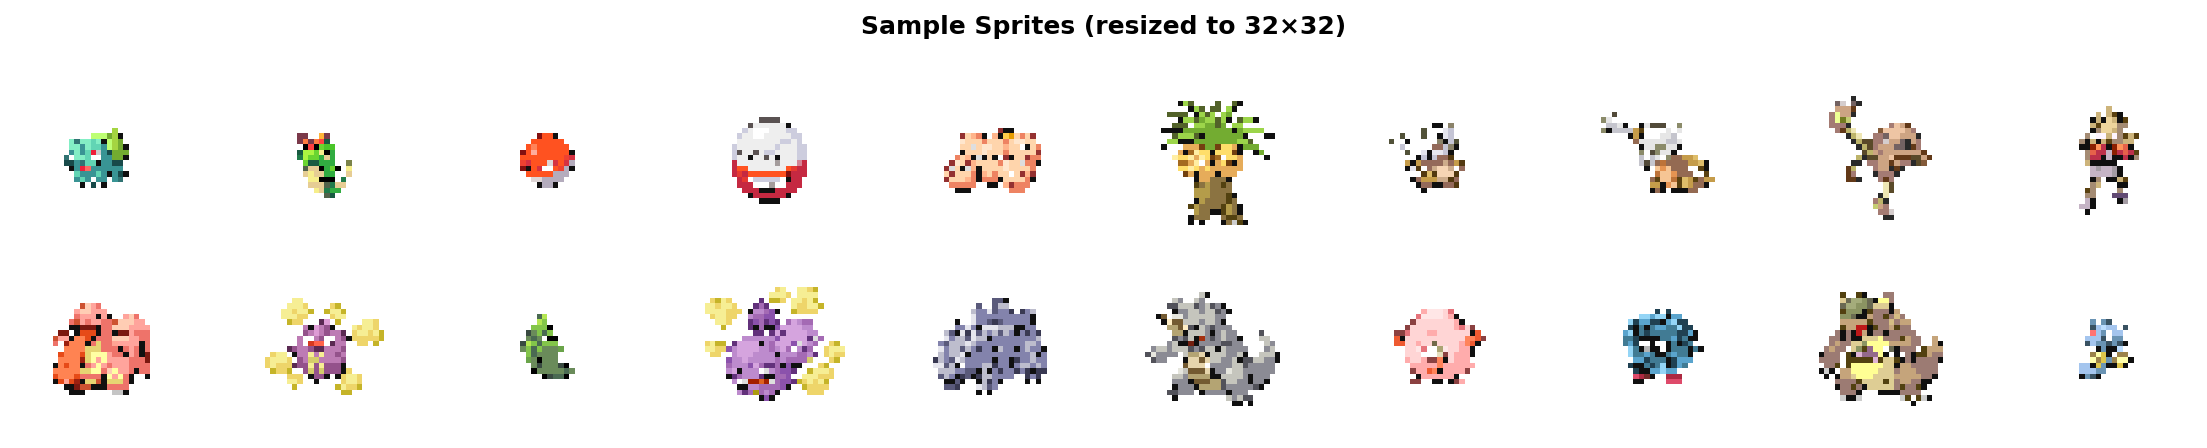

In [5]:
# Show some raw resized sprites
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i, ax in enumerate(axes.flat):
    if i < len(images):
        ax.imshow(images[i])
    ax.axis('off')
fig.suptitle('Sample Sprites (resized to 32×32)', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Palette Extraction via K-Means

In [6]:
# Extract 16-color palette
extractor = PaletteExtractor(palette_size=16)
extractor.fit(images)

palette = extractor.palette
print(f'Palette shape: {palette.shape}')
print(f'Palette colors (RGB):')
for i, c in enumerate(palette):
    print(f'  [{i:2d}] ({c[0]:3d}, {c[1]:3d}, {c[2]:3d})  #{c[0]:02x}{c[1]:02x}{c[2]:02x}')

  Total pixels collected: 204,800
  Running MiniBatchKMeans with k=16...
  Palette extracted: (16, 3)
Palette shape: (16, 3)
Palette colors (RGB):
  [ 0] ( 12,  12,  12)  #0c0c0c
  [ 1] (117,  63,  34)  #753f22
  [ 2] ( 61,  79, 101)  #3d4f65
  [ 3] (221,  87,  55)  #dd5737
  [ 4] (123, 150,  82)  #7b9652
  [ 5] (166, 131, 104)  #a68368
  [ 6] ( 92, 160, 214)  #5ca0d6
  [ 7] (164, 137, 176)  #a489b0
  [ 8] (227, 194,  73)  #e3c249
  [ 9] (227, 209, 180)  #e3d1b4
  [10] (237, 240, 246)  #edf0f6
  [11] (255, 255, 255)  #ffffff
  [12] (255, 255, 255)  #ffffff
  [13] (255, 255, 255)  #ffffff
  [14] (255, 255, 255)  #ffffff
  [15] (255, 255, 255)  #ffffff


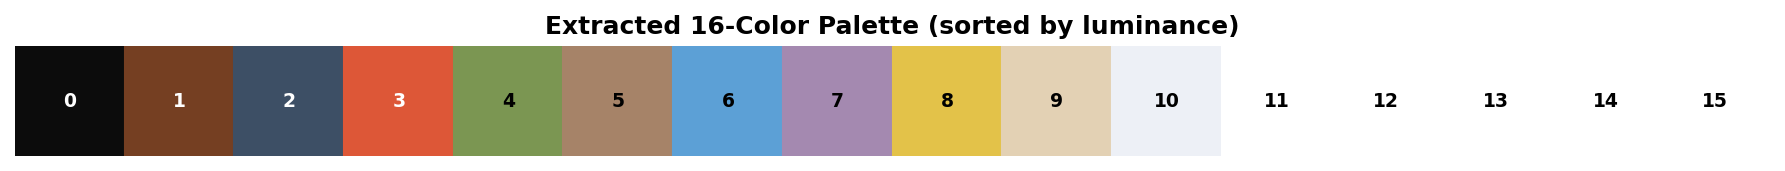

In [7]:
# Visualize palette
fig, ax = plt.subplots(1, 1, figsize=(12, 1.5))
for i, color in enumerate(palette):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=color / 255.0))
    lum = 0.299 * color[0] + 0.587 * color[1] + 0.114 * color[2]
    tc = 'white' if lum < 128 else 'black'
    ax.text(i + 0.5, 0.5, str(i), ha='center', va='center', fontsize=9, color=tc, fontweight='bold')
ax.set_xlim(0, len(palette))
ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Extracted 16-Color Palette (sorted by luminance)', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Palette Quantization: Original → Indexed

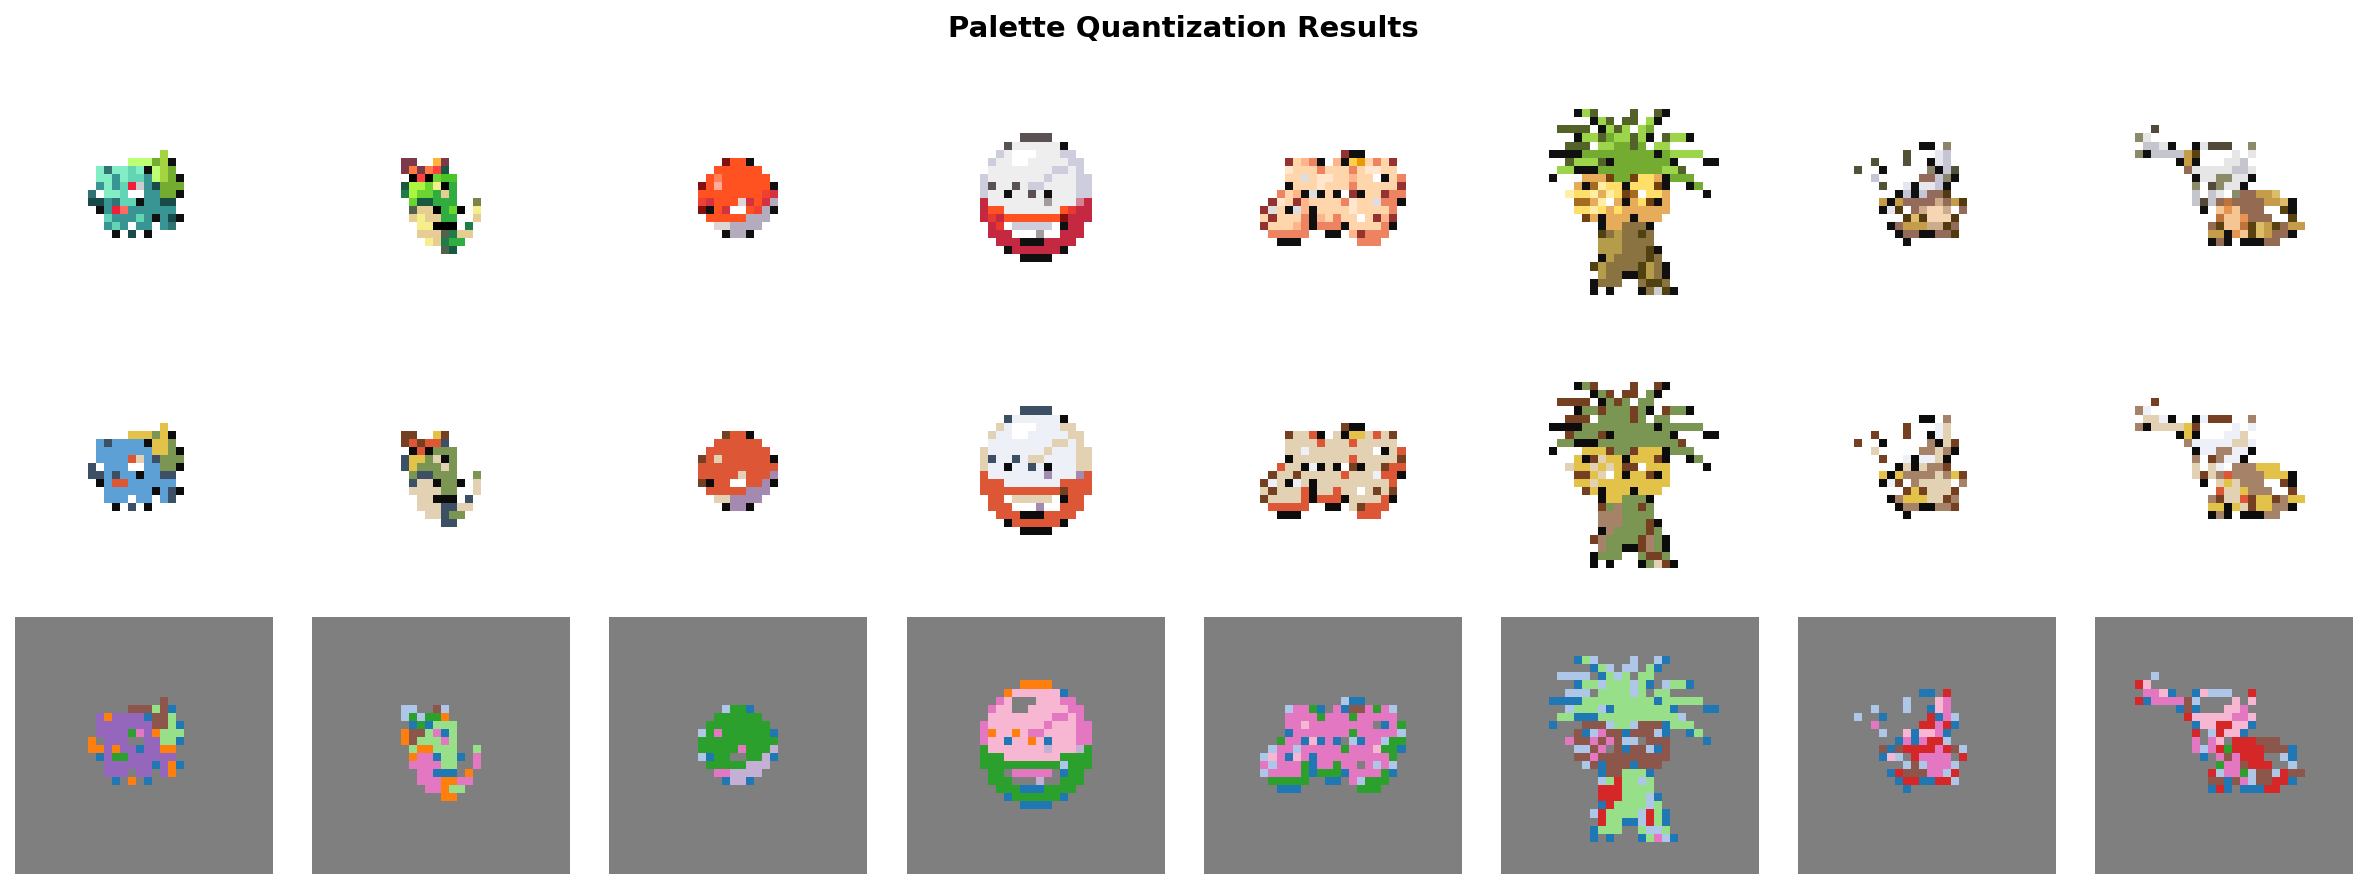

In [8]:
# Quantize sample images
n_show = 8
fig, axes = plt.subplots(3, n_show, figsize=(n_show * 2, 6))

for i in range(n_show):
    idx_map, quant = extractor.quantize(images[i])
    
    axes[0, i].imshow(images[i])
    axes[0, i].axis('off')
    
    axes[1, i].imshow(quant)
    axes[1, i].axis('off')
    
    axes[2, i].imshow(idx_map, cmap='tab20', vmin=0, vmax=15)
    axes[2, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Quantized', fontsize=11, fontweight='bold')
axes[2, 0].set_ylabel('Index Map', fontsize=11, fontweight='bold')
fig.suptitle('Palette Quantization Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Multi-Scale Decomposition (VAR-style)

This is the key insight of our approach: we decompose each sprite into a hierarchy of palette-index maps at increasing resolutions (1×1 → 2×2 → 4×4 → 8×8 → 16×16 → 32×32), matching how the VAR Transformer will generate them coarse-to-fine.

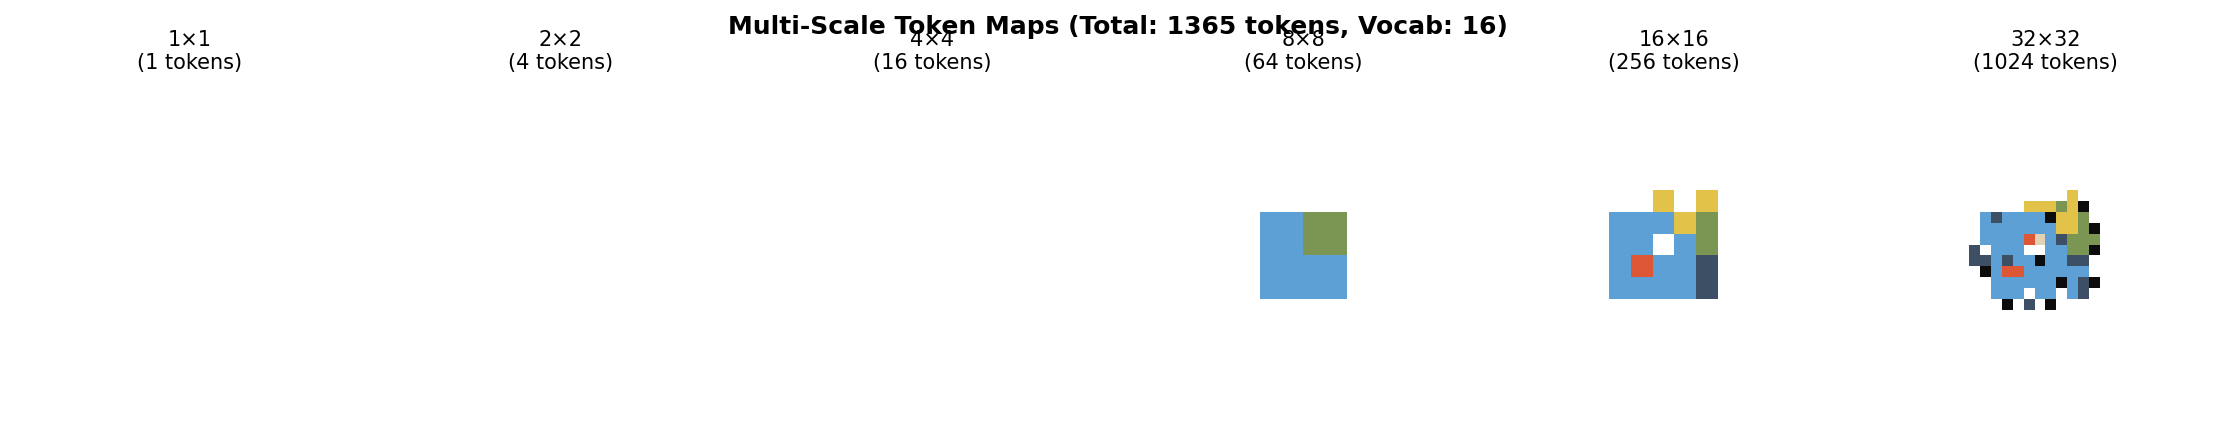

Total tokens per image: 1365
Token breakdown: 1 + 4 + 16 + 64 + 256 + 1024 = 1365


In [9]:
# Multi-scale visualization for a single sprite
scales = [1, 2, 4, 8, 16, 32]
sample_idx = 0
idx_map, _ = extractor.quantize(images[sample_idx])

fig, axes = plt.subplots(1, len(scales), figsize=(len(scales) * 2.5, 3))

total_tokens = 0
for si, res in enumerate(scales):
    h, w = idx_map.shape
    if res == h:
        scale_map = idx_map
    else:
        block_h = h // res
        block_w = w // res
        scale_map = np.zeros((res, res), dtype=np.uint8)
        for i in range(res):
            for j in range(res):
                block = idx_map[i*block_h:(i+1)*block_h, j*block_w:(j+1)*block_w]
                values, counts = np.unique(block, return_counts=True)
                scale_map[i, j] = values[np.argmax(counts)]
    
    n_tokens = res * res
    total_tokens += n_tokens
    
    rgb = palette[scale_map]
    axes[si].imshow(rgb)
    axes[si].set_title(f'{res}×{res}\n({n_tokens} tokens)', fontsize=10)
    axes[si].axis('off')

fig.suptitle(f'Multi-Scale Token Maps (Total: {total_tokens} tokens, Vocab: {len(palette)})', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Total tokens per image: {total_tokens}')
print(f'Token breakdown: {" + ".join(str(s*s) for s in scales)} = {total_tokens}')

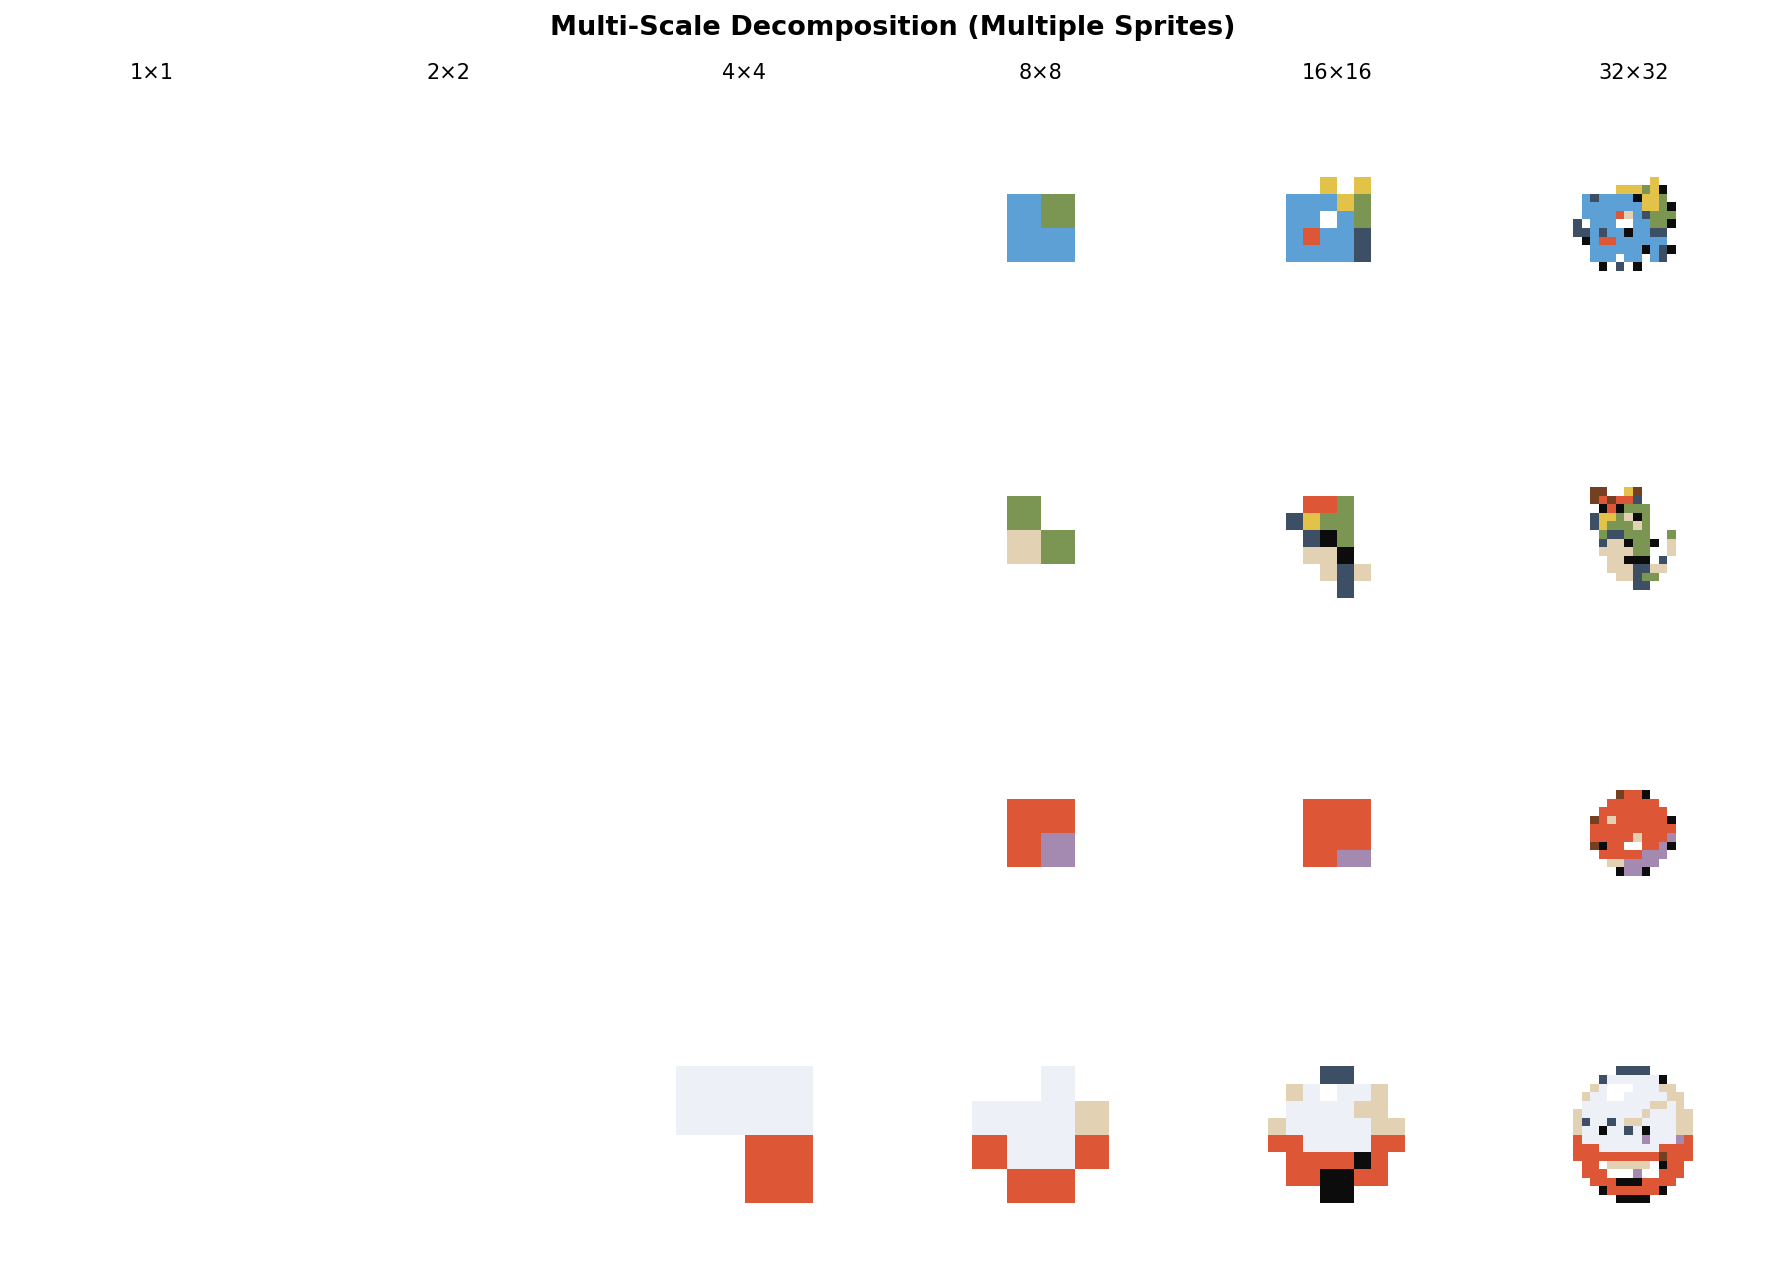

In [10]:
# Multi-scale for multiple sprites
n_sprites = 4
fig, axes = plt.subplots(n_sprites, len(scales), figsize=(len(scales) * 2, n_sprites * 2.2))

for row in range(n_sprites):
    idx_map, _ = extractor.quantize(images[row])
    for si, res in enumerate(scales):
        h, w = idx_map.shape
        if res == h:
            scale_map = idx_map
        else:
            block_h = h // res
            block_w = w // res
            scale_map = np.zeros((res, res), dtype=np.uint8)
            for i in range(res):
                for j in range(res):
                    block = idx_map[i*block_h:(i+1)*block_h, j*block_w:(j+1)*block_w]
                    values, counts = np.unique(block, return_counts=True)
                    scale_map[i, j] = values[np.argmax(counts)]
        
        rgb = palette[scale_map]
        axes[row, si].imshow(rgb)
        axes[row, si].axis('off')
        if row == 0:
            axes[row, si].set_title(f'{res}×{res}', fontsize=10)

fig.suptitle('Multi-Scale Decomposition (Multiple Sprites)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. PyTorch DataLoader Integration

In [11]:
# Run preprocessing if processed data doesn't exist yet (e.g., on Colab)
processed_dir = Path('data/processed/pokemon')
if not (processed_dir / 'index_maps.npy').exists():
    print('Processed data not found — running preprocessing script...')
    !python scripts/preprocess_data.py --dataset pokemon --palette-size 16
    print()

# Test the DataLoader
if processed_dir.exists() and (processed_dir / 'index_maps.npy').exists():
    dataset = PixelArtDataset(str(processed_dir))
    loader = get_dataloader(str(processed_dir), batch_size=8, num_workers=0)
    
    batch = next(iter(loader))
    print(f'Batch keys: {list(batch.keys())}')
    print(f'index_map shape: {batch["index_map"].shape}')
    print(f'token_sequence shape: {batch["token_sequence"].shape}')
    print(f'rgb shape: {batch["rgb"].shape}')
    print(f'Number of scales: {len(batch["multi_scale_maps"])}')
    for i, m in enumerate(batch['multi_scale_maps']):
        print(f'  Scale {i}: {m.shape}')
    
    print(f'\nToken sequence range: [{batch["token_sequence"].min()}, {batch["token_sequence"].max()}]')
    print(f'Vocabulary size: {dataset.palette_size}')
    print(f'Total tokens per image: {batch["token_sequence"].shape[1]}')
else:
    print('Run preprocessing first:')
    print('  python scripts/preprocess_data.py --dataset pokemon')

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/pokemon/index_maps.npy'

## 7. Dataset Statistics

In [ ]:
# Quantize all loaded images and compute stats
all_indices = []
for img in images:
    idx_map, _ = extractor.quantize(img)
    all_indices.append(idx_map)
all_indices = np.array(all_indices)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Palette index frequency
flat = all_indices.flatten()
ax1.hist(flat, bins=np.arange(17) - 0.5, edgecolor='black', alpha=0.7, color='steelblue')
ax1.set_xlabel('Palette Index')
ax1.set_ylabel('Frequency')
ax1.set_title('Palette Index Distribution')
ax1.set_xticks(range(16))

# Unique colors per sprite
unique_per = [len(np.unique(m)) for m in all_indices]
ax2.hist(unique_per, bins=range(1, 18), edgecolor='black', alpha=0.7, color='coral')
ax2.set_xlabel('# Unique Colors Used')
ax2.set_ylabel('# Sprites')
ax2.set_title(f'Colors per Sprite (mean={np.mean(unique_per):.1f})')

plt.suptitle('Dataset Statistics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Total images: {len(all_indices)}')
print(f'Image shape: {all_indices[0].shape}')
print(f'Avg unique colors per sprite: {np.mean(unique_per):.1f}')
print(f'Min/Max unique colors: {np.min(unique_per)}/{np.max(unique_per)}')

## Summary

### Milestone 1 — Completed
- **Datasets**: Pokemon sprites downloaded (905 sprites), with scripts ready for Sprites dataset (170K) and OpenGameArt
- **Preprocessing**: All images resized to 32×32 with nearest-neighbor interpolation
- **Palette extraction**: 16-color palette via MiniBatchKMeans, sorted by luminance
- **Quantization**: Every pixel mapped to nearest palette index → (32,32) index maps
- **Multi-scale maps**: 6 scales (1×1 to 32×32) = 1,365 tokens per sprite, vocabulary size 16
- **DataLoader**: PyTorch Dataset providing batched multi-scale token sequences

### Next: Milestone 2 (due 04/25)
- Train the multi-scale VQ-VAE tokenizer with L1 + perceptual loss
- Verify reconstruction quality at each scale
- Ablate codebook size (8 vs 16 vs 32)